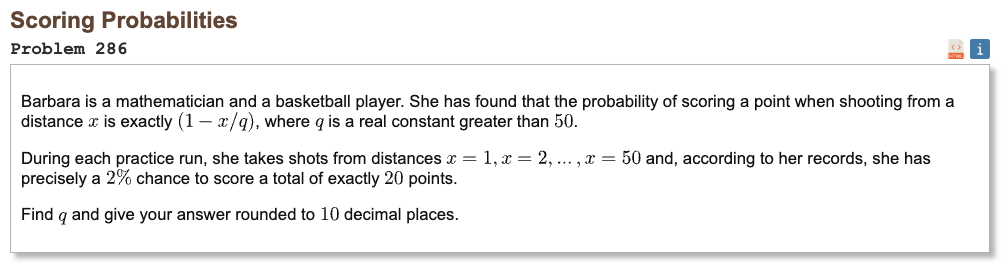

## Initial approach

-   treat each shot as an independent yes or no event, but with a different success chance at each distance
-   the chance from distance x is 1 - x/q, so as q changes, all 50 shot probabilities change together
-   the main job is to compute the probability of getting exactly 20 makes out of the 50 distances from 1 to 50
-   a simple dynamic programming table works well here because it builds the exact-k-success probability step by step after each shot
-   let dp[k] mean the probability of having exactly k made shots so far
-   for each new distance, update the table backward so earlier values are not overwritten too soon
-   then define a function f(q) as the probability of exactly 20 points, and search for the q where f(q)=0.02
-   since this probability decreases as q gets larger, binary search gives the answer cleanly

In [1]:
def exact_probability(q):
    dp = [0.0] * 51
    dp[0] = 1.0

    for x in range(1, 51):
        p = 1.0 - x / q
        for k in range(x, 0, -1):
            dp[k] = dp[k] * (1.0 - p) + dp[k - 1] * p
        dp[0] *= (1.0 - p)

    return dp[20]

low = 50.0
high = 100.0

for _ in range(100):
    mid = (low + high) / 2
    if exact_probability(mid) > 0.02:
        low = mid
    else:
        high = mid

In [2]:
%%time
result = (low + high) / 2
print("Result:", round(result, 10))

Result: 52.6494571953
CPU times: user 85 μs, sys: 8 μs, total: 93 μs
Wall time: 89.2 μs
